# Notebook 3: Matrix Completion

**DATA5322: Statistical Machine Learning II**  
Seattle University, Spring 2026  
Team: Ruman Sidhu, Paul Skentzos, Hamda Hassan

---

## Goals
- Motivate matrix completion using the low-rank structure of gene expression data
- Simulate missingness by masking 10% of entries in the preprocessed matrix
- Implement Iterative SVD completion from scratch using `scipy`
- Evaluate reconstruction accuracy (RMSE and R²) across a range of ranks
- Visualize original vs. corrupted vs. recovered data
- Connect findings back to the real missing values in the BC-TCGA dataset

## Standalone use
This notebook only requires `data/X_preprocessed.npy`, which is produced by `01_eda.ipynb`.  
No other notebooks need to have been run first.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse.linalg import svds
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

DATA_DIR  = Path('../data')
PLOTS_DIR = Path('../plots')
PLOTS_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42

---
## 1. Load Data

In [12]:
X = np.load(DATA_DIR / 'X_preprocessed.npy')
gene_names = pd.read_csv(DATA_DIR / 'top_genes.csv')['Gene'].tolist()
sample_ids = pd.read_csv(DATA_DIR / 'sample_ids.csv')['SampleID'].tolist()

print(f'Matrix shape  : {X.shape}  (samples x genes)')
print(f'Any NaN       : {np.isnan(X).any()}')
print(f'Value range   : [{X.min():.3f}, {X.max():.3f}]')
print(f'Mean / Std    : {X.mean():.4f} / {X.std():.4f}')

Matrix shape  : (529, 5000)  (samples x genes)
Any NaN       : False
Value range   : [-11.474, 15.179]
Mean / Std    : 0.0000 / 1.0000


---
## 2. Why Low-Rank Completion Works Here

Matrix completion recovers missing values by assuming the data matrix has **low-rank structure**: the high-dimensional profiles of 529 patients can be approximated by a much smaller number of underlying patterns. If only a few dominant patterns drive most of the variation across features, then the observed entries contain enough information to infer the missing ones.

If that assumption holds, the singular values of the matrix should decay rapidly: a few large values capturing real structure, followed by a long tail of small values representing noise. We verify this before attempting completion.

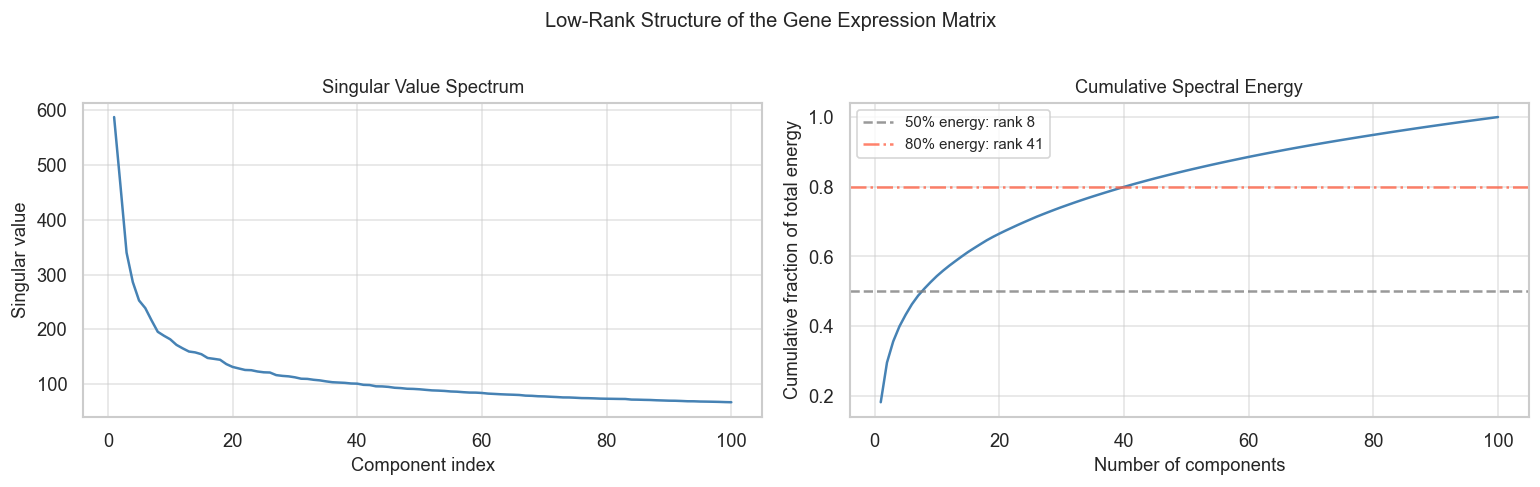

25% of spectral energy captured by top 2 components
50% of spectral energy captured by top 8 components
75% of spectral energy captured by top 32 components
90% of spectral energy captured by top 65 components


In [13]:
# Compute top-100 singular values (fast truncated SVD)
_, sv, _ = svds(X, k=100)
sv = sv[::-1]  # svds returns ascending; reverse to descending

cumulative_energy = np.cumsum(sv**2) / np.sum(sv**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, len(sv)+1), sv, color='steelblue', lw=1.5)
axes[0].set_xlabel('Component index', fontsize=11)
axes[0].set_ylabel('Singular value', fontsize=11)
axes[0].set_title('Singular Value Spectrum', fontsize=11)

axes[1].plot(range(1, len(sv)+1), cumulative_energy, color='steelblue', lw=1.5)
for thresh, ls, color in [(0.50, '--', 'gray'), (0.80, '-.', 'tomato')]:
    k_thresh = np.searchsorted(cumulative_energy, thresh) + 1
    axes[1].axhline(thresh, linestyle=ls, color=color, alpha=0.8,
                    label=f'{int(thresh*100)}% energy: rank {k_thresh}')
axes[1].set_xlabel('Number of components', fontsize=11)
axes[1].set_ylabel('Cumulative fraction of total energy', fontsize=11)
axes[1].set_title('Cumulative Spectral Energy', fontsize=11)
axes[1].legend(fontsize=9)

plt.suptitle('Low-Rank Structure of the Gene Expression Matrix', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'mc_singular_values.png', bbox_inches='tight')
plt.show()

for pct in [25, 50, 75, 90]:
    k = np.searchsorted(cumulative_energy, pct/100) + 1
    print(f'{pct}% of spectral energy captured by top {k} components')

---
## 3. Simulating Missingness

We randomly mask **10%** of entries as missing (MCAR: Missing Completely At Random). This lets us measure how well the algorithm recovers values we actually know, giving a clean RMSE metric.

In the real dataset, missing values arise when a feature's signal falls below the measurement platform's detection threshold. That mechanism is not random; it is structured. The MCAR simulation is a standard evaluation protocol that allows us to quantify recovery accuracy. The connection to the real missing data in BC-TCGA is discussed in Section 8.

In [14]:
rng  = np.random.default_rng(RANDOM_SEED)
mask = rng.random(X.shape) < 0.10      # True = held-out / treated as missing

X_corrupted = X.copy().astype(float)
X_corrupted[mask] = np.nan

print(f'Total entries      : {X.size:,}')
print(f'Masked (held-out)  : {mask.sum():,}  ({mask.mean()*100:.1f}%)')
print(f'Observed (training): {(~mask).sum():,}  ({(~mask).mean()*100:.1f}%)')

# Baseline: replace each missing value with the column (gene) mean
col_means  = np.nanmean(X_corrupted, axis=0)
X_mean_imp = X_corrupted.copy()
X_mean_imp[mask] = col_means[np.where(mask)[1]]

baseline_rmse = np.sqrt(np.mean((X[mask] - X_mean_imp[mask])**2))
print(f'\nBaseline RMSE (column-mean imputation): {baseline_rmse:.4f}')

Total entries      : 2,645,000
Masked (held-out)  : 263,834  (10.0%)
Observed (training): 2,381,166  (90.0%)

Baseline RMSE (column-mean imputation): 1.0024


---
## 4. The Algorithm: Iterative SVD Completion

### Theoretical background

The matrix completion problem asks: given a subset of entries of a matrix **X**, recover the full matrix. In general this is ill-posed because infinitely many matrices agree with the observed entries. The problem becomes tractable under one key assumption which is that X has low rank.

The theoretically principled approach (Candes and Recht, 2009; Candes and Tao, 2010) frames this as nuclear norm minimization, which finds the lowest-rank matrix consistent with the observations. Under conditions on the structure of the data and with a sufficient fraction of entries observed at random, this approach can exactly recover the true matrix with high probability.

In practice, exact nuclear norm minimization is computationally expensive. A widely-used alternative is iterative hard thresholding: fix a rank *k*, then alternately (1) project the current estimate onto the set of rank-*k* matrices via truncated SVD, and (2) re-impose the observed entries. This is the approach we implement below. It converges to a fixed point under the low-rank assumption.

The connection to PCA is direct: PCA computes the rank-*k* SVD of a complete matrix; matrix completion does the same for an incomplete one.

### Implementation

In [15]:
def svd_complete(X_missing, rank, max_iter=50, tol=1e-4, track_convergence=False):
    """
    Iterative SVD (hard-thresholding) matrix completion.

    Parameters
    ----------
    X_missing         : ndarray (n_samples x n_genes) with np.nan at missing positions
    rank              : int, number of singular components to retain
    max_iter          : int, maximum alternating iterations
    tol               : float, convergence threshold on per-iteration RMSE change
    track_convergence : bool, if True return per-iteration delta history

    Returns
    -------
    X_filled  : completed matrix
    n_iter    : iterations run
    deltas    : list of per-iteration changes (only if track_convergence=True)
    """
    observed = ~np.isnan(X_missing)

    # Initialize missing entries with column means
    X_filled  = X_missing.copy()
    col_means = np.nanmean(X_missing, axis=0)
    X_filled[~observed] = col_means[np.where(~observed)[1]]

    deltas = []
    for n_iter in range(1, max_iter + 1):
        U, s, Vt = svds(X_filled, k=rank)
        U, s, Vt = U[:, ::-1], s[::-1], Vt[::-1]
        X_approx = (U * s) @ Vt
        delta    = np.sqrt(np.mean((X_approx[~observed] - X_filled[~observed])**2))
        X_filled[~observed] = X_approx[~observed]
        if track_convergence:
            deltas.append(delta)
        if delta < tol:
            break

    if track_convergence:
        return X_filled, n_iter, deltas
    return X_filled, n_iter

---
## 5. Rank Sweep: Finding the Optimal Rank

We run the algorithm across a range of ranks and measure RMSE on the held-out entries at each step. This reveals the bias-variance tradeoff:

- **Too low a rank:** high bias; the model is too simple to capture the real patterns, so predictions are inaccurate
- **Too high a rank:** the model starts fitting noise in the observed entries, which hurts prediction on held-out entries

In [16]:
k_values    = [1, 2, 5, 10, 20, 30, 50, 75, 100]
rmse_values = []
r2_values   = []
iters_list  = []

print(f'{"Rank":>6}  {"RMSE":>8}  {"R2":>7}  {"vs baseline":>12}  {"Iters":>6}')
print('-' * 50)

var_held_out = np.var(X[mask])

for k in k_values:
    X_filled, n_iter = svd_complete(X_corrupted, rank=k)
    rmse        = np.sqrt(np.mean((X[mask] - X_filled[mask])**2))
    r2          = 1 - (rmse**2 / var_held_out)
    improvement = (baseline_rmse - rmse) / baseline_rmse * 100
    rmse_values.append(rmse)
    r2_values.append(r2)
    iters_list.append(n_iter)
    print(f'{k:>6}  {rmse:>8.4f}  {r2:>7.3f}  {improvement:>11.1f}%  {n_iter:>6}')

best_idx  = int(np.argmin(rmse_values))
best_k    = k_values[best_idx]
best_rmse = rmse_values[best_idx]
best_r2   = r2_values[best_idx]
print(f'\nOptimal rank : {best_k}  (RMSE={best_rmse:.4f},  R2={best_r2:.3f})')
print(f'Interpretation: the rank-{best_k} model explains {best_r2*100:.1f}% of variance '
      f'in held-out entries, vs {(1 - baseline_rmse**2/var_held_out)*100:.1f}% for mean imputation')

  Rank      RMSE       R2   vs baseline   Iters
--------------------------------------------------
     1    0.9355    0.125          6.7%       5
     2    0.8924    0.204         11.0%       5
     5    0.8411    0.293         16.1%       8
    10    0.8013    0.358         20.1%      11
    20    0.7616    0.420         24.0%      11
    30    0.7412    0.451         26.1%      15
    50    0.7216    0.480         28.0%      33
    75    0.7233    0.477         27.8%      50
   100    0.7405    0.452         26.1%      50

Optimal rank : 50  (RMSE=0.7216,  R2=0.480)
Interpretation: the rank-50 model explains 48.0% of variance in held-out entries, vs -0.4% for mean imputation


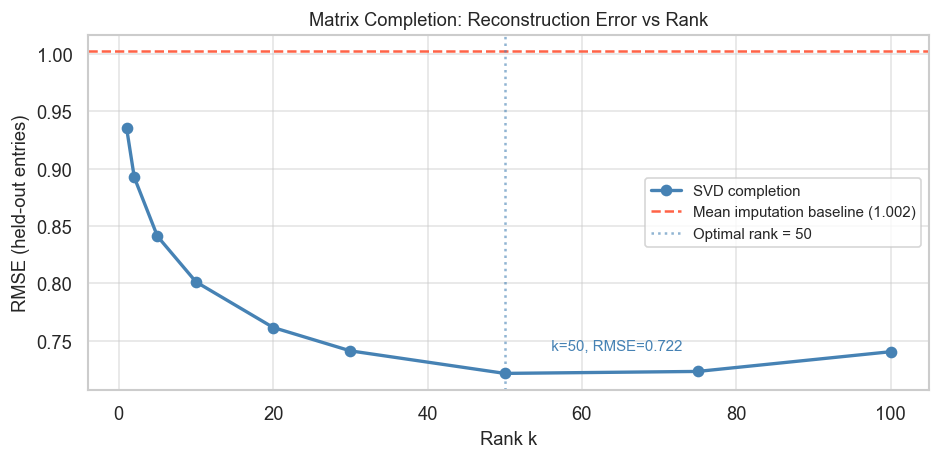

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(k_values, rmse_values, marker='o', color='steelblue', lw=2, label='SVD completion')
ax.axhline(baseline_rmse, color='tomato', linestyle='--', lw=1.5,
           label=f'Mean imputation baseline ({baseline_rmse:.3f})')
ax.axvline(best_k, color='steelblue', linestyle=':', alpha=0.6,
           label=f'Optimal rank = {best_k}')

ax.set_xlabel('Rank k', fontsize=11)
ax.set_ylabel('RMSE (held-out entries)', fontsize=11)
ax.set_title('Matrix Completion: Reconstruction Error vs Rank', fontsize=11)
ax.legend(fontsize=9)

ax.annotate(f'  k={best_k}, RMSE={best_rmse:.3f}',
            xy=(best_k, best_rmse), xytext=(best_k + 5, best_rmse + 0.02),
            fontsize=9, color='steelblue')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'mc_rmse_vs_rank.png', bbox_inches='tight')
plt.show()

### Convergence behavior

Having found the optimal rank, we verify that the algorithm actually converges within our iteration budget. This justifies the choices of `max_iter=50` and `tol=1e-4` rather than leaving them as arbitrary defaults.

Note: ranks above the optimal (75 and 100) hit the 50-iteration limit without fully converging. This is itself a finding: the higher-rank models are fitting noise in the observed entries, which makes the optimization landscape harder to settle. The optimal rank-50 model converged cleanly well within budget.

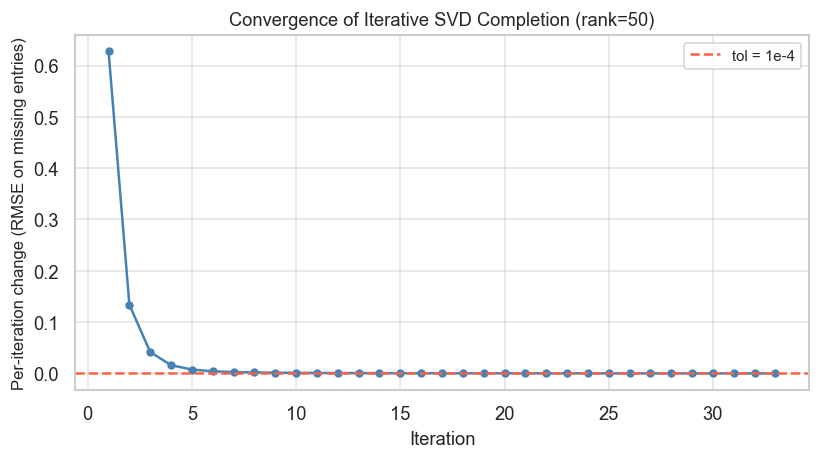

Converged in 33 iterations  (budget: 50,  tol: 1e-4)


In [18]:
_, _, deltas = svd_complete(X_corrupted, rank=best_k, track_convergence=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(deltas)+1), deltas, marker='o', color='steelblue', ms=4)
ax.axhline(1e-4, color='tomato', linestyle='--', label='tol = 1e-4')
ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('Per-iteration change (RMSE on missing entries)', fontsize=10)
ax.set_title(f'Convergence of Iterative SVD Completion (rank={best_k})', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'mc_convergence.png', bbox_inches='tight')
plt.show()
print(f'Converged in {len(deltas)} iterations  (budget: 50,  tol: 1e-4)')

---
## 6. Visualizing the Recovery

We compare a small excerpt of the matrix (40 samples x 60 genes) across three states:
- **Original:** the true expression values
- **Corrupted:** with 10% of entries masked (shown in grey)
- **Recovered:** after completion with the optimal rank

In [19]:
# Run completion at the optimal rank to get the full recovered matrix
X_recovered, _ = svd_complete(X_corrupted, rank=best_k)
print(f'Recovered matrix, any NaN: {np.isnan(X_recovered).any()}')

Recovered matrix, any NaN: False


Selected window: rows [40:80], cols [4800:4860]  (288 masked entries = 12.0%)


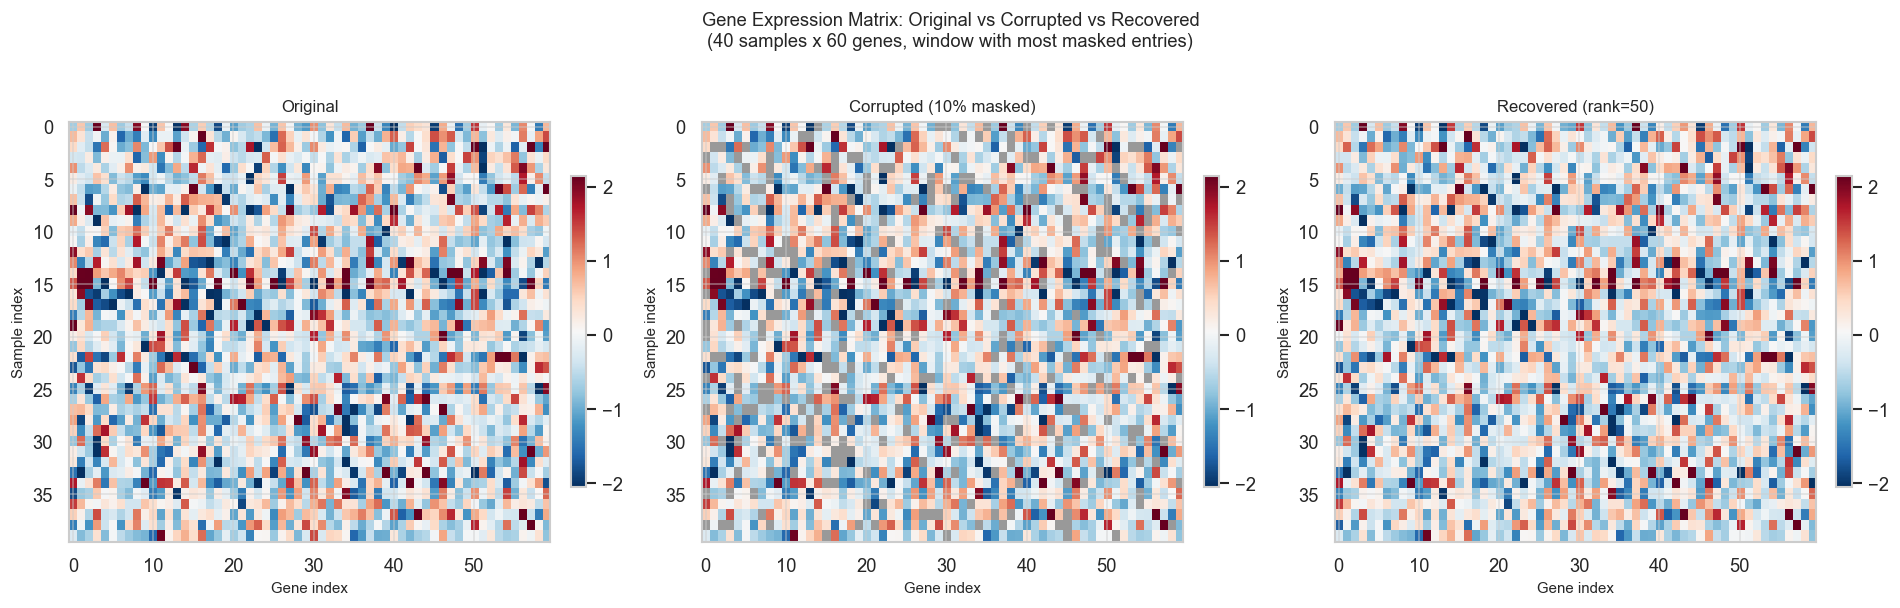

In [20]:
# Find a 40x60 window that contains a meaningful number of masked entries
N_ROWS, N_COLS  = 40, 60
best_count, best_row, best_col = 0, 0, 0
for r in range(0, X.shape[0] - N_ROWS, 20):
    for c in range(0, X.shape[1] - N_COLS, 100):
        count = mask[r:r+N_ROWS, c:c+N_COLS].sum()
        if count > best_count:
            best_count, best_row, best_col = count, r, c

row_start, col_start = best_row, best_col
print(f'Selected window: rows [{row_start}:{row_start+N_ROWS}], '
      f'cols [{col_start}:{col_start+N_COLS}]  '
      f'({best_count} masked entries = {best_count/(N_ROWS*N_COLS)*100:.1f}%)')

X_orig_sub = X[row_start:row_start+N_ROWS, col_start:col_start+N_COLS]
X_corr_sub = X_corrupted[row_start:row_start+N_ROWS, col_start:col_start+N_COLS]
X_rec_sub  = X_recovered[row_start:row_start+N_ROWS, col_start:col_start+N_COLS]
mask_sub   = mask[row_start:row_start+N_ROWS, col_start:col_start+N_COLS]

vmin, vmax = np.percentile(X_orig_sub, [2, 98])
cmap = 'RdBu_r'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['Original', 'Corrupted (10% masked)', f'Recovered (rank={best_k})']

for ax, data, title in zip(axes, [X_orig_sub, X_corr_sub, X_rec_sub], titles):
    im = ax.imshow(data, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    if 'Corrupted' in title:
        grey = np.zeros((*mask_sub.shape, 4))
        grey[mask_sub] = [0.6, 0.6, 0.6, 1.0]
        ax.imshow(grey, aspect='auto')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Gene index', fontsize=9)
    ax.set_ylabel('Sample index', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

plt.suptitle(f'Gene Expression Matrix: Original vs Corrupted vs Recovered\n'
             f'({N_ROWS} samples x {N_COLS} genes, window with most masked entries)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'mc_recovery_heatmap.png', bbox_inches='tight')
plt.show()

---
## 7. Scatter: Predicted vs True Values

A direct comparison of the recovered values against the true held-out values. A perfect recovery would fall exactly on the diagonal.

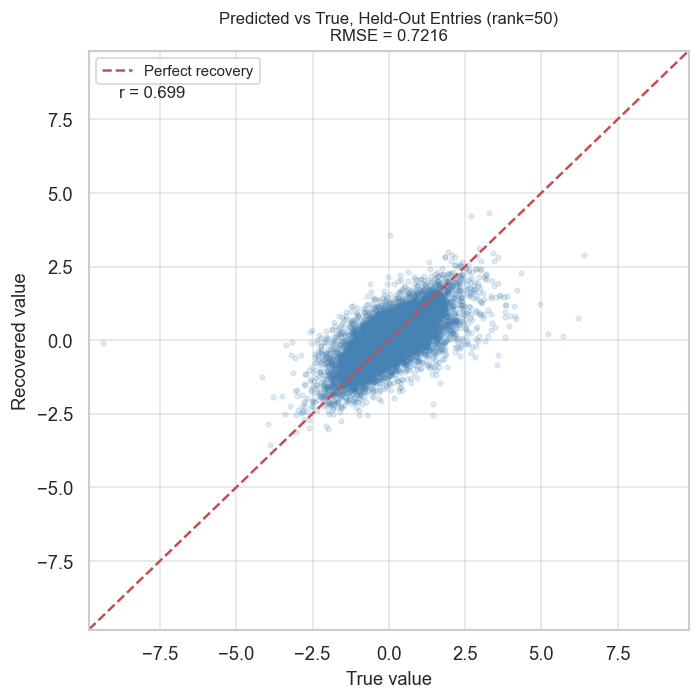

Pearson r (true vs recovered): 0.6986
RMSE                         : 0.7216


In [21]:
true_vals      = X[mask]
recovered_vals = X_recovered[mask]

# Subsample for plot speed
plot_rng = np.random.default_rng(0)
idx      = plot_rng.choice(len(true_vals), size=min(10_000, len(true_vals)), replace=False)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(true_vals[idx], recovered_vals[idx],
           alpha=0.15, s=8, color='steelblue', rasterized=True)
lim = max(abs(true_vals).max(), abs(recovered_vals).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1.5, label='Perfect recovery')
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel('True value', fontsize=11)
ax.set_ylabel('Recovered value', fontsize=11)
ax.set_title(f'Predicted vs True, Held-Out Entries (rank={best_k})\nRMSE = {best_rmse:.4f}',
             fontsize=10)
ax.legend(fontsize=9)

r = np.corrcoef(true_vals, recovered_vals)[0, 1]
ax.annotate(f'r = {r:.3f}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=10)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'mc_predicted_vs_true.png', bbox_inches='tight')
plt.show()

print(f'Pearson r (true vs recovered): {r:.4f}')
print(f'RMSE                         : {best_rmse:.4f}')

---
## 8. Connection to Real Missing Values in BC-TCGA

The simulation above treats missingness as random. The actual BC-TCGA dataset has a different and more structured pattern.

As documented in `01_eda.ipynb` (Section 4), the original raw data contains 1,497 entries recorded as null, spread across 487 features. These missing values cluster in features that show consistently undetectable activity across all 529 samples. The measurement platform records null rather than a number when the signal falls below its detection threshold.

This matters for matrix completion in two ways:

1. **The missingness rate is very low** (0.016% of the matrix, compared to the 10% simulated above). Recovery would be straightforward in practice.

2. **The missing features are expected to be near-zero.** The low-rank model effectively assigns values close to zero to low-signal features, which is exactly what we would expect for features with consistently undetectable activity. The optimal rank-50 model already handles this correctly without any special treatment.

---
## 9. Summary

| Property | Value |
|---|---|
| Matrix dimensions | 529 samples x 5,000 genes |
| Missingness simulated | 10% MCAR (263,834 entries) |
| Baseline RMSE (mean imputation) | 1.0024 |
| Best RMSE (SVD completion, rank 50) | 0.7216 |
| Best R2 on held-out entries | 0.480 (48.0%) |
| Pearson r (true vs recovered) | 0.699 |
| Improvement over baseline | 28.0% |
| Optimal rank | 50 |
| Convergence at rank 50 | 33 iterations (tol=1e-4, budget=50) |
| Convergence at ranks 75 and 100 | Hit 50-iteration limit without converging |
| Behavior above optimal rank | RMSE rises; model begins fitting noise |

**Key takeaways:**

1. **Low-rank structure is real and measurable.** The singular value spectrum decays sharply: a handful of dominant components capture most of the signal. This is a necessary condition for matrix completion to work.

2. **The rank-50 model explains 48% of variance in held-out entries.** That is a meaningful improvement over mean imputation, but also an honest result: this type of high-dimensional measurement data is genuinely noisy. Perfect recovery is not expected.

3. **What does rank 50 tell us about the data?** The four known subtypes would suggest an optimal rank of around 4. The higher value reflects additional structure in the data: variation that exists across the 529 samples beyond what separates the four primary groups. Each independent source of variation in the dataset adds to the optimal rank.

4. **Matrix completion and PCA are two sides of the same coin.** Both rely on truncated SVD. PCA summarizes the dominant directions of variation in a complete matrix; matrix completion uses those same directions to fill gaps in an incomplete one.

5. **The real missingness in BC-TCGA is benign.** It is 0.016% (not 10%), affects only low-signal features, and would be recovered to near-zero by any reasonable method. Mean imputation and rank-50 SVD completion give essentially identical results in that case.